#### Índices de seguridad por modo de transporte: caminando, manejando y motocicleta
#### César Villarreal Hernández

Objetivo: una función **(latitud, longitud, hora, modo) → (SI_delito, SI_vial)** para usar como pesos en el algoritmo multiobjetivo de rutas.

- **SI_delito**: riesgo de sufrir un delito. Solo cuentan los delitos que le pueden pasar a quien va en ese modo (a quien camina le roban la cartera, a quien maneja el coche). Se predice con los mismos pipelines que en Spaceship Titanic: `Pipeline` por modelo, `cross_validate`, conjunto de prueba aparte y `GridSearchCV`.
- **SI_vial**: riesgo de sufrir un accidente, con los datos de siniestros viales (`siniestralimap`). Solo cuentan las personas que iban en ese modo, ponderadas por la gravedad del accidente.

Los dos índices van de 0 a 100 y **no se suman**: el algoritmo los usa como dos objetivos separados junto con la distancia. Tampoco se comparan entre modos: cada uno se normaliza con su propio percentil 99, así que un 50 caminando no equivale a un 50 manejando.

**Configuración**

Los pesos de cada delito combinan **qué tan grave es** y **qué tan expuesto está** quien va en ese modo. Se toma como referencia la fórmula original del SI (violentos 0.7, robos 0.3) y se ajusta por modo. Se excluyen los delitos que ocurren dentro de casas o negocios (violencia familiar, abuso sexual infantil, robo a casa habitación, a negocio, a bancos, a carga pesada), porque no le pasan a quien va de paso.

En manejando, el robo de autopartes lleva peso bajo porque muchos son robos a autos estacionados: miden más el riesgo de dejar el auto en esa zona que el de pasar por ella.

In [1]:
import numpy as np
import pandas as pd

PERCENTIL = 0.99   # tope de la normalizacion de los indices
TAM_CELDA = 0.5    # km

# proyeccion local a km (a 20.6 grados de latitud)
LAT0, LON0 = 20.6, -103.4
KM_POR_GRADO_LAT, KM_POR_GRADO_LON = 110.7, 104.2

MODOS = ["caminando", "manejando", "motocicleta"]

# peso de cada delito en el SI_delito de cada modo (los que no aparecen no cuentan)
PESOS_DELITO = {
    "caminando":   {"Robo a persona": 0.3, "Robo a cuentahabientes": 0.3,
                    "Lesiones dolosas": 0.7, "Homicidio doloso": 0.7, "Violacion": 0.7},
    "manejando":   {"Robo a vehiculos particulares": 0.5, "Robo a int de vehiculos": 0.3,
                    "Robo de autopartes": 0.15, "Lesiones dolosas": 0.2, "Homicidio doloso": 0.2},
    "motocicleta": {"Robo de motocicleta": 0.5, "Robo a persona": 0.3,
                    "Lesiones dolosas": 0.5, "Homicidio doloso": 0.5},
}

# personas del registro de siniestros que cuentan para el SI_vial de cada modo
USUARIO_VIAL = {"caminando": "Peaton", "manejando": "Vehiculo particular", "motocicleta": "Motociclista"}

# peso de cada persona segun la consecuencia del accidente
PESO_GRAVEDAD = {"Fallecido": 5, "Lesionado": 2, "Ileso": 0.5, "Desconocido": 1}

pd.DataFrame(PESOS_DELITO).fillna("-")

,caminando,manejando,motocicleta
Robo a persona,0.3,-,0.3
Robo a cuentahabientes,0.3,-,-
Lesiones dolosas,0.7,0.2,0.5
Homicidio doloso,0.7,0.2,0.5
Violacion,0.7,-,-
Robo a vehiculos particulares,-,0.5,-
Robo a int de vehiculos,-,0.3,-
Robo de autopartes,-,0.15,-
Robo de motocicleta,-,-,0.5


**Delitos: construcción del dataset**

In [2]:
d = pd.read_csv("Crime_Population.csv", usecols=["delito", "x", "y", "hora", "año"])

# observamos el porcentaje de valores faltantes para cada columna
d.isna().sum()/d.shape[0]*100

delito    0.000000
x         1.885073
y         1.885073
año       0.000000
hora      9.885609
dtype: float64

Los delitos sin coordenadas u hora no se pueden asignar a una celda-hora, así que se descartan. La ciudad se divide en celdas de 500 m y cada celda se cruza con las 24 horas. Las celdas-hora sin delitos entran con índice 0; si no, el modelo nunca vería momentos tranquilos.

In [3]:
d = d.dropna(subset=["x", "y", "hora"])
d["hora"] = d["hora"].astype(int)
d["ix"] = ((d["x"] - LON0) * KM_POR_GRADO_LON // TAM_CELDA).astype(int)
d["iy"] = ((d["y"] - LAT0) * KM_POR_GRADO_LAT // TAM_CELDA).astype(int)

# malla: todas las celdas con al menos un delito x 24 horas
celdas = d[["ix", "iy"]].drop_duplicates()
malla = celdas.merge(pd.DataFrame({"hora": range(24)}), how="cross")
malla["lon"] = LON0 + (malla["ix"] + 0.5) * TAM_CELDA / KM_POR_GRADO_LON
malla["lat"] = LAT0 + (malla["iy"] + 0.5) * TAM_CELDA / KM_POR_GRADO_LAT

# hora ciclica: las 23 y las 0 quedan juntas
malla["hora_sin"] = np.sin(2 * np.pi * malla["hora"] / 24)
malla["hora_cos"] = np.cos(2 * np.pi * malla["hora"] / 24)

# conteo de cada tipo de delito por celda-hora
conteos = (d.groupby(["ix", "iy", "hora", "delito"]).size().unstack(fill_value=0)
            .reindex(pd.MultiIndex.from_frame(malla[["ix", "iy", "hora"]]), fill_value=0))


def normalizar(x):
    """escala 0-100 con tope en el percentil 99"""
    tope = np.quantile(x, PERCENTIL)
    return 100 * np.clip(x, None, tope) / tope


for modo in MODOS:
    pesos = pd.Series(PESOS_DELITO[modo])
    x = (conteos[pesos.index] * pesos).sum(axis=1).to_numpy()
    malla[f"SI_delito_{modo}"] = normalizar(x)
    n = int(conteos[pesos.index].to_numpy().sum())
    print(f"{modo:12s} {n:7,} delitos | {(malla[f'SI_delito_{modo}'] == 0).mean():.0%} de celda-hora en cero")

print(f"\n{len(celdas):,} celdas x 24 horas = {len(malla):,} celda-hora")

caminando     87,242 delitos | 64% de celda-hora en cero
manejando    107,156 delitos | 61% de celda-hora en cero
motocicleta   98,612 delitos | 62% de celda-hora en cero

4,342 celdas x 24 horas = 104,208 celda-hora


**Exploratory Data Analysis**

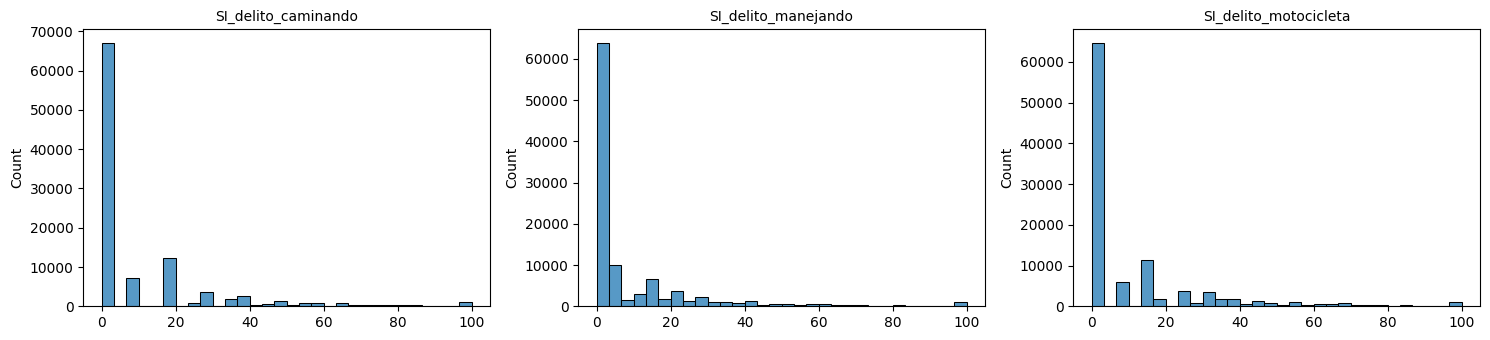

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

objetivos = [f"SI_delito_{modo}" for modo in MODOS]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, objetivos):
    sns.histplot(malla[col], bins=30, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()

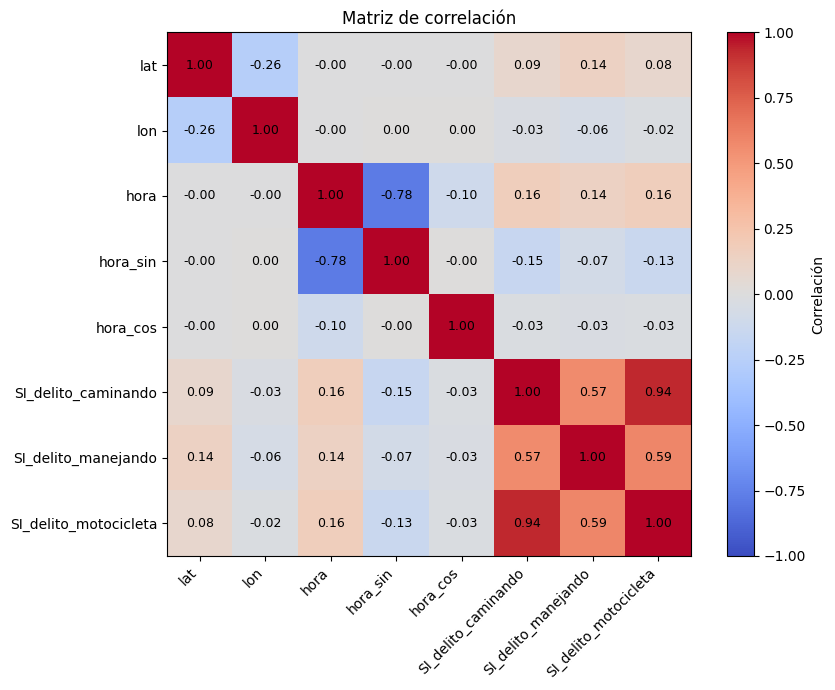

In [5]:
# correlacion entre las features y los indices de cada modo
corr_matrix = malla[["lat", "lon", "hora", "hora_sin", "hora_cos"] + objetivos].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Los tres índices están cargados a la izquierda (muchas celdas-hora en 0), por eso Gradient Boosting usa pérdida **Poisson**, pensada para conteos. Las correlaciones lineales con lat, lon y hora son bajas: el riesgo se concentra en focos, no sigue una tendencia en el mapa.

**Pipelines para el SI_delito**

Una misma celda aparece 24 veces (una por hora); si unas horas quedan en train y otras en test, el modelo "ya conoce" la celda. Por eso se separa **por celda** con `GroupShuffleSplit` y la validación cruzada usa `GroupKFold` con la misma llave. Es el equivalente a no partir un grupo de viaje entre folds en Spaceship Titanic. La separación es la misma para los tres modos.

In [6]:
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

features = ["lat", "lon", "hora", "hora_sin", "hora_cos"]
X = malla[features]
# llave de grupo: la celda (todas sus horas van juntas)
grupos = malla["ix"].astype(str) + "_" + malla["iy"].astype(str)

# separamos nuestro conjunto de datos: 20% de las celdas quedan fuera para la prueba final
split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
idx_tr, idx_te = next(split.split(X, groups=grupos))
X_tr, X_te = X.iloc[idx_tr], X.iloc[idx_te]
grupos_tr = grupos.iloc[idx_tr]


def spearman(y_real, y_pred):
    # correlacion de rangos: importa mas el orden (que celda es mas riesgosa) que el valor exacto
    return spearmanr(y_real, y_pred)[0]


SCORING = {
    "r2":       "r2",                            # varianza del indice explicada por el modelo
    "mae":      "neg_mean_absolute_error",       # error promedio en puntos del indice
    "rmse":     "neg_root_mean_squared_error",   # como el MAE pero castiga mas los errores grandes
    "spearman": make_scorer(spearman),
}

cv = GroupKFold(n_splits=5)

print(f"train: {len(X_tr):,} filas ({grupos_tr.nunique():,} celdas) | test: {len(X_te):,} filas")

train: 83,352 filas (3,473 celdas) | test: 20,856 filas


In [7]:
pipelines = []

pipelines.append(("Regresion-Lineal",
                 Pipeline(steps=[("imputer",    SimpleImputer(strategy="median")), # por si llega un punto con datos faltantes
                                ("scaler",      StandardScaler()),                 # estandariza cada feature
                                ("regressor",   LinearRegression())]               # baseline lineal
                                 )))

# KNN: el scaler no es opcional aqui, el modelo se basa en distancias
pipelines.append(("KNN",
                 Pipeline(steps=[("imputer",    SimpleImputer(strategy="median")),
                                ("scaler",      StandardScaler()),
                                ("regressor",   KNeighborsRegressor(n_neighbors=15, weights="distance"))]
                                 )))

pipelines.append(("SGDRegressor",
                 Pipeline(steps=[("imputer",    SimpleImputer(strategy="median")),
                                ("scaler",      StandardScaler()),                 # SGD necesita features en la misma escala
                                ("regressor",   SGDRegressor(max_iter=1000, random_state=0))]
                                 )))

# los arboles no dependen de la escala de las features, asi que no llevan scaler
pipelines.append(("RandomForest",
                 Pipeline(steps=[("imputer",    SimpleImputer(strategy="median")),
                                ("regressor",   RandomForestRegressor(n_estimators=100,
                                                                      min_samples_leaf=20,
                                                                      max_features=0.6,
                                                                      n_jobs=-1,
                                                                      random_state=0))]
                                 )))

pipelines.append(("HistGradientBoosting",
                 Pipeline(steps=[("imputer",    SimpleImputer(strategy="median")),
                                ("regressor",   HistGradientBoostingRegressor(loss="poisson",   # el indice viene de conteos
                                                                              learning_rate=0.05,
                                                                              max_iter=400,
                                                                              min_samples_leaf=40,
                                                                              random_state=0))]
                                 )))
resultados = []

for modo in MODOS:
    y_tr = malla[f"SI_delito_{modo}"].iloc[idx_tr]
    y_te = malla[f"SI_delito_{modo}"].iloc[idx_te]
    print(f"==================== {modo.upper()} ====================")

    for name, pipe in pipelines:
        cross_val_results = cross_validate(
            pipe, X_tr, y_tr,
            groups=grupos_tr,     # GroupKFold necesita saber a que celda pertenece cada fila
            cv=cv,
            scoring=SCORING,
            return_train_score=True,
            error_score="raise",  # el default es np.nan y oculta fallos
        )

        fila = {"Modo": modo, "Modelo": name}
        for metric in SCORING:
            # las metricas de error vienen negativas (sklearn siempre maximiza), les regresamos el signo
            signo = -1 if metric in ("mae", "rmse") else 1
            fila[metric.upper()] = signo * cross_val_results[f"test_{metric}"].mean()
        fila["R2 train"] = cross_val_results["train_r2"].mean()

        # cross_validate clona el pipeline, asi que el modelo de prueba se entrena aparte
        fila["R2 TEST"] = clone(pipe).fit(X_tr, y_tr).score(X_te, y_te)
        print(f"{name:22s} R2 = {fila['R2']:.3f} ± {cross_val_results['test_r2'].std():.3f} | "
              f"train = {fila['R2 train']:.3f} | MAE = {fila['MAE']:5.2f} | "
              f"SPEARMAN = {fila['SPEARMAN']:.3f} | TEST = {fila['R2 TEST']:.3f}")
        resultados.append(fila)

pd.DataFrame(resultados).set_index(["Modo", "Modelo"]).round(3)

==================== CAMINANDO ====================


Regresion-Lineal       R2 = 0.035 ± 0.002 | train = 0.036 | MAE = 14.08 | SPEARMAN = 0.195 | TEST = 0.036


KNN                    R2 = 0.347 ± 0.008 | train = 1.000 | MAE = 10.38 | SPEARMAN = 0.558 | TEST = 0.331


SGDRegressor           R2 = 0.035 ± 0.003 | train = 0.036 | MAE = 14.11 | SPEARMAN = 0.192 | TEST = 0.035


RandomForest           R2 = 0.358 ± 0.011 | train = 0.477 | MAE = 10.23 | SPEARMAN = 0.577 | TEST = 0.345


...

KNN                    R2 = 0.382 ± 0.013 | train = 1.000 | MAE = 10.01 | SPEARMAN = 0.588 | TEST = 0.370


SGDRegressor           R2 = 0.032 ± 0.002 | train = 0.033 | MAE = 13.98 | SPEARMAN = 0.180 | TEST = 0.034


RandomForest           R2 = 0.385 ± 0.013 | train = 0.505 | MAE =  9.91 | SPEARMAN = 0.601 | TEST = 0.373


HistGradientBoosting   R2 = 0.391 ± 0.008 | train = 0.533 | MAE =  9.77 | SPEARMAN = 0.607 | TEST = 0.384


R2     MAE    RMSE  SPEARMAN  R2 train  \
Modo        Modelo                                                            
caminando   Regresion-Lineal      0.035  14.084  19.846     0.195     0.036   
            KNN                   0.347  10.380  16.332     0.558     1.000   
            SGDRegressor          0.035  14.106  19.852     0.192     0.036   
            RandomForest          0.358  10.226  16.188     0.577     0.477   
            HistGradientBoosting  0.363  10.093  16.128     0.583     0.496   
manejando   Regresion-Lineal      0.040  11.654  17.811     0.227     0.041   
            KNN                   0.492   7.660  12.936     0.598     1.000   
            SGDRegressor          0.039  11.646  17.821     0.228     0.040   
            RandomForest          0.483   7.667  13.058     0.610     0.579   
            HistGradientBoosting  0.486   7.567  13.010     0.616     0.592   
motocicleta Regresion-Lineal      0.033  13.950  19.702     0.183     0.034   
            KNN                   0.382  10.014  15.743     0.588     1.000   
            SGDRegressor          0.032  13.982  19.709     0.180     0.033   
            RandomForest          0.385   9.912  15.715     0.601     0.505   
            HistGradientBoosting  0.391   9.765  15.632     0.607     0.533   

                                  R2 TEST  
Modo        Modelo                         
caminando   Regresion-Lineal        0.036  
            KNN                     0.331  
            SGDRegressor            0.035  
            RandomForest            0.345  
            HistGradientBoosting    0.354  
manejando   Regresion-Lineal        0.041  
            KNN                     0.501  
            SGDRegressor            0.041  
            RandomForest            0.491  
            HistGradientBoosting    0.483  
motocicleta Regresion-Lineal        0.035  
            KNN                     0.370  
            SGDRegressor            0.034  
            RandomForest            0.373  
            HistGradientBoosting    0.384

**Búsqueda de hiperparámetros (GridSearchCV)**

Se ajusta Gradient Boosting para cada modo. Se usan los mismos grupos por celda para que ninguna celda se parta entre folds. En la versión anterior el mejor `max_leaf_nodes` quedó en el límite de la rejilla (63), así que ahora se prueban árboles más grandes.

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__learning_rate":    [0.05, 0.1],
    "regressor__max_leaf_nodes":   [31, 63, 127],
    "regressor__min_samples_leaf": [20, 40, 80],
    "regressor__max_iter":         [400],
}
hgb_base = dict(pipelines)["HistGradientBoosting"]

busquedas = {}
for modo in MODOS:
    # se busca sobre el pipeline completo: los parametros del modelo llevan el prefijo "regressor__"
    gs = GridSearchCV(clone(hgb_base), param_grid, cv=GroupKFold(n_splits=5), scoring="r2", n_jobs=-1)
    gs.fit(X_tr, malla[f"SI_delito_{modo}"].iloc[idx_tr], groups=grupos_tr)   # sin groups= GroupKFold lanza ValueError
    busquedas[modo] = gs
    mejores = {k.replace("regressor__", ""): v for k, v in gs.best_params_.items()}
    print(f"{modo:12s} R2 = {gs.best_score_:.4f} | {mejores}")

caminando    R2 = 0.3654 | {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 40}


manejando    R2 = 0.4888 | {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 40}


motocicleta  R2 = 0.3922 | {'learning_rate': 0.05, 'max_iter': 400, 'max_leaf_nodes': 63, 'min_samples_leaf': 40}


**Evaluación final en el conjunto de prueba**

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

filas = []
for modo in MODOS:
    y_tr = malla[f"SI_delito_{modo}"].iloc[idx_tr]
    y_te = malla[f"SI_delito_{modo}"].iloc[idx_te]
    # GridSearchCV reentrena el mejor pipeline con todo X_tr (refit=True por default)
    for name, modelo in (("HGB default", clone(hgb_base).fit(X_tr, y_tr)),
                         ("HGB GridSearch", busquedas[modo].best_estimator_)):
        # el indice vive entre 0 y 100; el modelo puede pasarse un poco en los extremos
        pred = np.clip(modelo.predict(X_te), 0, 100)
        filas.append({"Modo": modo, "Modelo": name,
                      "R2":       r2_score(y_te, pred),
                      "MAE":      mean_absolute_error(y_te, pred),
                      "RMSE":     root_mean_squared_error(y_te, pred),
                      "Spearman": spearman(y_te, pred)})
pd.DataFrame(filas).set_index(["Modo", "Modelo"]).round(3)

R2     MAE    RMSE  Spearman
Modo        Modelo                                         
caminando   HGB default     0.354  10.218  15.914     0.578
            HGB GridSearch  0.363  10.014  15.813     0.585
manejando   HGB default     0.483   7.693  13.129     0.624
            HGB GridSearch  0.496   7.518  12.966     0.627
motocicleta HGB default     0.384   9.777  15.337     0.605
            HGB GridSearch  0.390   9.599  15.266     0.612

In [10]:
# modelo final de cada modo: el mejor pipeline reentrenado con todas las celdas
modelos_delito = {}
for modo in MODOS:
    modelos_delito[modo] = clone(busquedas[modo].best_estimator_).fit(X, malla[f"SI_delito_{modo}"])
    malla[f"SI_delito_pred_{modo}"] = np.clip(modelos_delito[modo].predict(X), 0, 100)

**SI_vial: accidentes por modo**

In [11]:
s = pd.read_csv("siniestralimap-2026-09-30.csv", low_memory=False)

# observamos el porcentaje de valores faltantes (x, y son las coordenadas)
print((s[["x", "y", "rango_hora", "tipo_usuario", "consecuencia"]].isna().sum()/s.shape[0]*100).round(2))

# cada fila es una persona involucrada en un accidente
s = s.dropna(subset=["x", "y"])
s["ix"] = ((s["x"] - LON0) * KM_POR_GRADO_LON // TAM_CELDA).astype(int)
s["iy"] = ((s["y"] - LAT0) * KM_POR_GRADO_LAT // TAM_CELDA).astype(int)
s["h0"] = pd.to_numeric(s["rango_hora"].str[:2], errors="coerce")   # inicio del bloque de 2 h ("No especificado" -> NaN)
s["gravedad"] = s["consecuencia"].map(PESO_GRAVEDAD)

pd.crosstab(s["tipo_usuario"], s["consecuencia"]).loc[list(USUARIO_VIAL.values())]

x               8.8
y               8.8
rango_hora      0.0
tipo_usuario    0.0
consecuencia    0.0
dtype: float64


consecuencia,Desconocido,Fallecido,Ileso,Lesionado
tipo_usuario,,,,
Peaton,0,741,2,2670
Vehiculo particular,14,303,8050,5273
Motociclista,3,701,1036,8075


Con pocos accidentes por modo (hay ~1,800 peatones con coordenadas en 11 años) casi todas las celdas-hora quedarían en 0 y el índice sería puro ruido. Por eso no se entrena un modelo por celda-hora; se separa el **dónde** del **cuándo**:

`SI_vial(celda, hora) = N[ densidad de la celda (suavizada en el espacio) × perfil horario del modo ]`

- **Densidad**: gravedad acumulada en la celda, suavizada con un filtro gaussiano (una avenida atraviesa varias celdas). El ancho del filtro (`sigma`) es el hiperparámetro.
- **Perfil horario**: cómo se reparten los accidentes del modo a lo largo del día, uno solo para toda la ciudad (los datos vienen en bloques de 2 horas).

Supone que el patrón horario es el mismo en toda la ciudad. Es una simplificación, pero con tan pocos datos es mucho más estable que contar cada celda-hora por separado.

Para elegir `sigma` se usa una **validación temporal**: la densidad de 2015–2021 debe anticipar dónde ocurren los accidentes de 2022–2025. Se mide con Spearman sobre las celdas de la malla (importa el orden: qué celdas son más peligrosas).

In [12]:
from scipy.ndimage import gaussian_filter

# rejilla que cubre todas las celdas de la malla
IX0, IY0 = malla["ix"].min(), malla["iy"].min()
ANCHO, ALTO = malla["ix"].max() - IX0 + 1, malla["iy"].max() - IY0 + 1
fila_c, col_c = (celdas["iy"] - IY0).to_numpy(), (celdas["ix"] - IX0).to_numpy()


def raster_gravedad(sub):
    """gravedad acumulada de los accidentes de `sub` en cada celda de la rejilla"""
    dentro = sub["ix"].between(IX0, IX0 + ANCHO - 1) & sub["iy"].between(IY0, IY0 + ALTO - 1)
    sub = sub[dentro]
    R = np.zeros((ALTO, ANCHO))
    np.add.at(R, (sub["iy"] - IY0, sub["ix"] - IX0), sub["gravedad"])
    return R


def suavizar(R, sigma):
    return gaussian_filter(R, sigma, mode="constant") if sigma > 0 else R


SIGMAS = [0, 0.5, 1, 1.5, 2, 3]   # en celdas de 500 m (0 = sin suavizar)
validacion = {}
for modo in MODOS:
    sub = s[s["tipo_usuario"] == USUARIO_VIAL[modo]]
    viejo, nuevo = raster_gravedad(sub[sub["anio"] <= 2021]), raster_gravedad(sub[sub["anio"] >= 2022])
    validacion[modo] = {sg: spearman(nuevo[fila_c, col_c], suavizar(viejo, sg)[fila_c, col_c]) for sg in SIGMAS}

tabla_sigma = pd.DataFrame(validacion).rename_axis("sigma")
SIGMA_VIAL = tabla_sigma.idxmax().to_dict()
print("sigma elegido por modo:", SIGMA_VIAL)
tabla_sigma.round(3)

sigma elegido por modo: {'caminando': 0.0, 'manejando': 0.0, 'motocicleta': 0.0}


,caminando,manejando,motocicleta
sigma,,,
0.0,0.454,0.614,0.639
0.5,0.410,0.544,0.581
1.0,0.399,0.524,0.558
1.5,0.388,0.515,0.545
2.0,0.379,0.509,0.536
3.0,0.368,0.501,0.523


In [13]:
DENSIDAD, PERFIL, TOPE_VIAL = {}, {}, {}
horas = np.arange(24)

for modo in MODOS:
    sub = s[s["tipo_usuario"] == USUARIO_VIAL[modo]]

    # densidad final con todos los anios y el sigma elegido
    DENSIDAD[modo] = suavizar(raster_gravedad(sub), SIGMA_VIAL[modo])

    # perfil horario: gravedad de cada bloque de 2 h repartida entre sus dos horas, con promedio 1
    bloques = sub.dropna(subset=["h0"]).groupby("h0")["gravedad"].sum().reindex(range(0, 24, 2), fill_value=0)
    perfil = bloques.reindex(horas // 2 * 2).to_numpy() / 2
    PERFIL[modo] = perfil / perfil.mean()

    x = DENSIDAD[modo][malla["iy"] - IY0, malla["ix"] - IX0] * PERFIL[modo][malla["hora"]]
    TOPE_VIAL[modo] = np.quantile(x, PERCENTIL)
    malla[f"SI_vial_{modo}"] = 100 * np.clip(x, None, TOPE_VIAL[modo]) / TOPE_VIAL[modo]

malla[[f"SI_{tipo}_{modo}" for modo in MODOS for tipo in ("delito_pred", "vial")]].describe().round(2)

,SI_delito_pred_caminando,SI_vial_caminando,SI_delito_pred_manejando,SI_vial_manejando,SI_delito_pred_motocicleta,SI_vial_motocicleta
count,104208.00,104208.00,104208.00,104208.00,104208.00,104208.00
mean,11.01,5.67,9.26,7.03,11.31,8.19
std,13.01,15.64,13.30,17.53,13.42,18.13
min,0.02,0.00,0.01,0.00,0.02,0.00
25%,1.73,0.00,1.28,0.00,1.62,0.00
50%,5.83,0.00,3.64,0.00,5.82,0.00
75%,15.71,0.00,11.15,3.85,16.41,7.35
max,100.00,100.00,99.45,100.00,100.00,100.00


**Mapas y perfiles horarios**

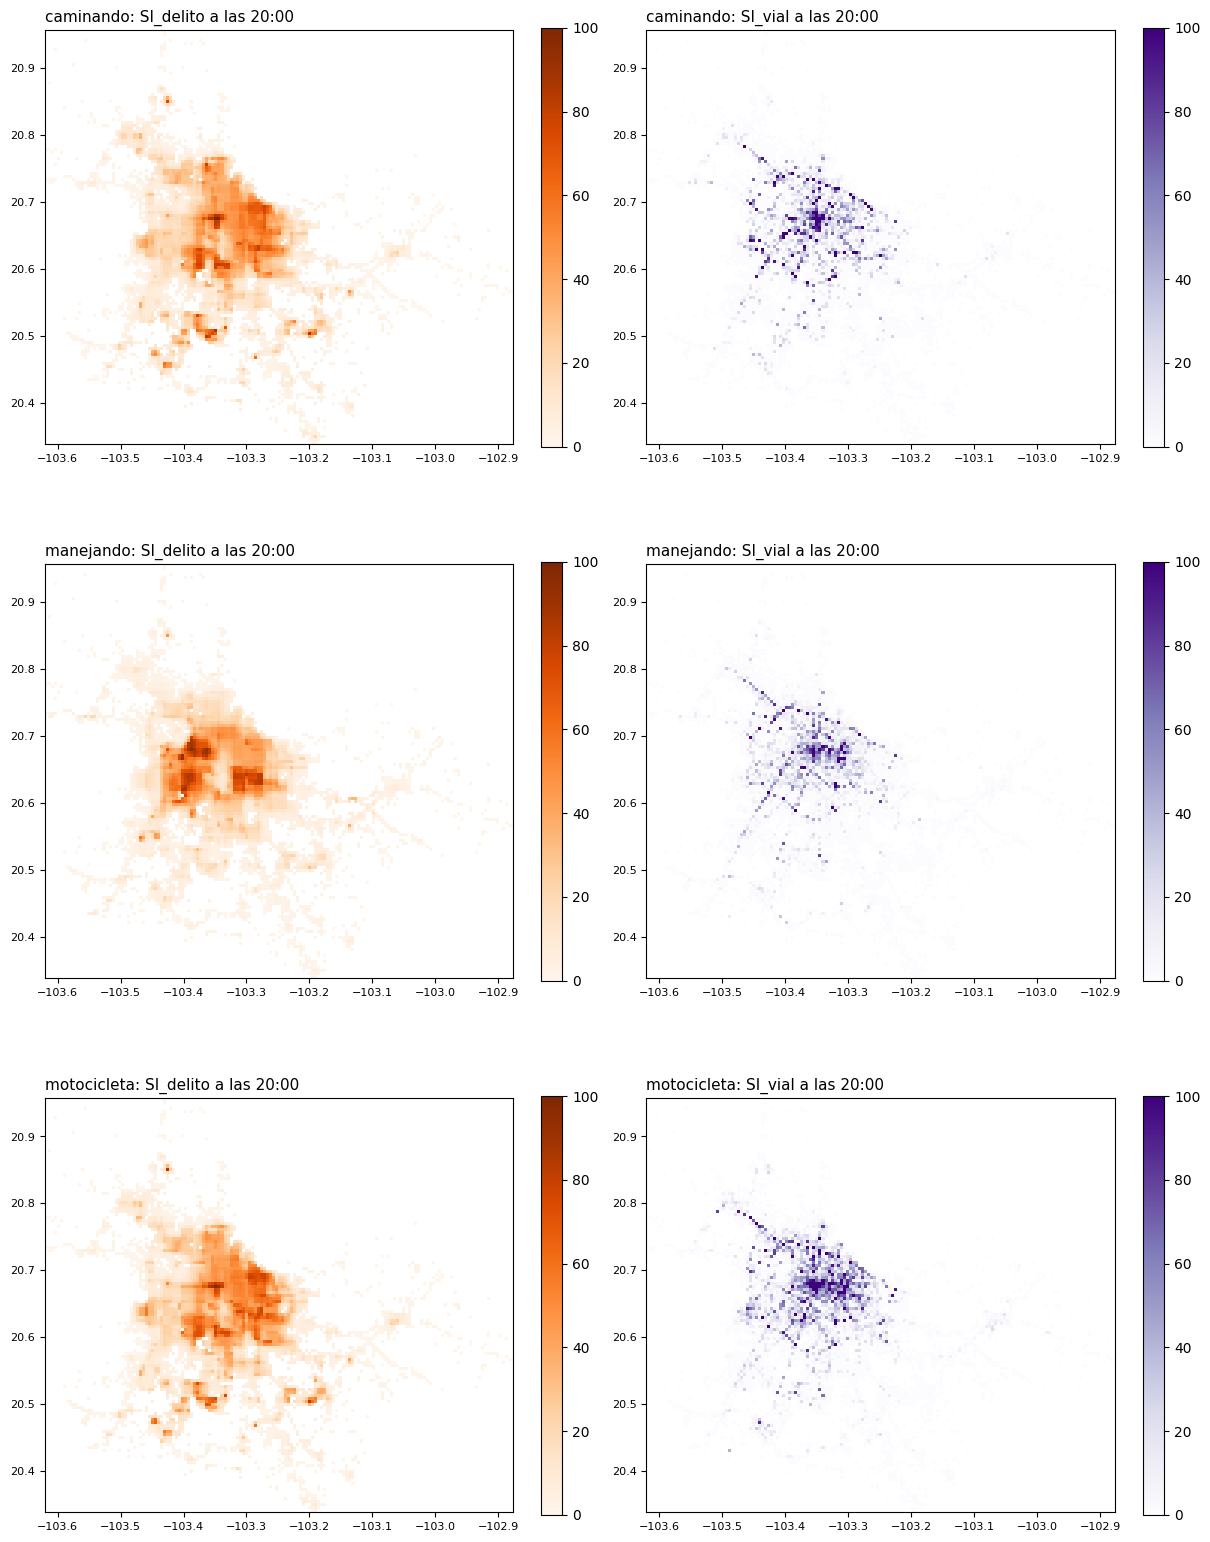

In [14]:
HORA_MAPA = 20
extension = [LON0 + IX0 * TAM_CELDA / KM_POR_GRADO_LON, LON0 + (IX0 + ANCHO) * TAM_CELDA / KM_POR_GRADO_LON,
             LAT0 + IY0 * TAM_CELDA / KM_POR_GRADO_LAT, LAT0 + (IY0 + ALTO) * TAM_CELDA / KM_POR_GRADO_LAT]
sub = malla[malla["hora"] == HORA_MAPA]

fig, axes = plt.subplots(3, 2, figsize=(12, 16), layout="constrained")
for fila_ax, modo in zip(axes, MODOS):
    for ax, (tipo, cmap) in zip(fila_ax, (("delito_pred", "Oranges"), ("vial", "Purples"))):
        raster = np.full((ALTO, ANCHO), np.nan)
        raster[sub["iy"] - IY0, sub["ix"] - IX0] = sub[f"SI_{tipo}_{modo}"]
        im = ax.imshow(raster, origin="lower", extent=extension, cmap=cmap, vmin=0, vmax=100,
                       interpolation="nearest")
        ax.set_aspect(KM_POR_GRADO_LAT / KM_POR_GRADO_LON)   # 1 km se ve igual en ambos ejes
        ax.set_title(f"{modo}: SI_{tipo.replace('_pred', '')} a las {HORA_MAPA}:00", fontsize=11, loc="left")
        ax.tick_params(labelsize=8)
        fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

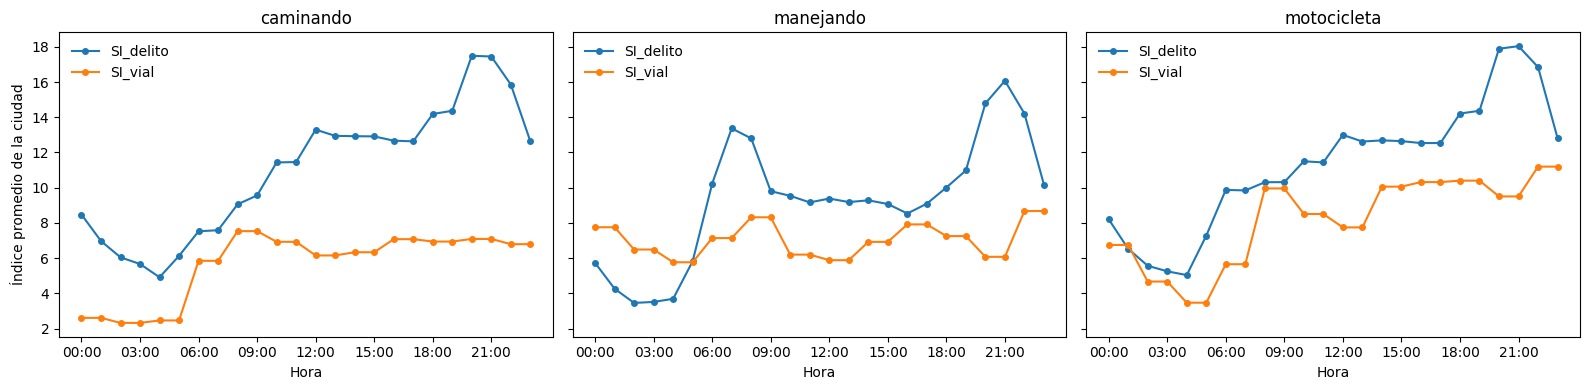

In [15]:
# perfil horario: indice promedio de la ciudad en cada hora
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, modo in zip(axes, MODOS):
    for tipo, etiqueta in (("delito_pred", "SI_delito"), ("vial", "SI_vial")):
        perfil = malla.groupby("hora")[f"SI_{tipo}_{modo}"].mean()
        ax.plot(perfil.index, perfil.values, marker="o", markersize=4, label=etiqueta)
    ax.set_xticks(range(0, 24, 3), [f"{h:02d}:00" for h in range(0, 24, 3)])
    ax.set_title(modo)
    ax.set_xlabel("Hora")
    ax.legend(frameon=False)
axes[0].set_ylabel("Índice promedio de la ciudad")
plt.tight_layout()
plt.show()

**Función final**

In [16]:
# FUNCION FINAL: SI_delito y SI_vial de cualquier punto, hora y modo
def indice(lat, lon, hora=None, modo="caminando"):
    """Indices (0-100) del punto (lat, lon) para el modo de transporte dado.

    - modo: "caminando", "manejando" o "motocicleta"
    - con hora (0-23): regresa (SI_delito, SI_vial)
    - sin hora: regresa un DataFrame con los dos indices en las 24 horas del dia
    """
    if modo not in MODOS:
        raise ValueError(f"modo debe ser uno de {MODOS}")
    horas = np.arange(24) if hora is None else np.array([int(hora) % 24])

    # SI_delito: el mejor pipeline del modo (mismas columnas y orden que en el entrenamiento)
    fila = pd.DataFrame({"lat": lat, "lon": lon, "hora": horas,
                         "hora_sin": np.sin(2 * np.pi * horas / 24),
                         "hora_cos": np.cos(2 * np.pi * horas / 24)})[features]
    si_delito = np.clip(modelos_delito[modo].predict(fila), 0, 100)

    # SI_vial: densidad de la celda x perfil horario (0 fuera de la rejilla)
    r = int((lat - LAT0) * KM_POR_GRADO_LAT // TAM_CELDA) - IY0
    c = int((lon - LON0) * KM_POR_GRADO_LON // TAM_CELDA) - IX0
    densidad = DENSIDAD[modo][r, c] if 0 <= r < ALTO and 0 <= c < ANCHO else 0.0
    si_vial = 100 * np.clip(densidad * PERFIL[modo][horas], None, TOPE_VIAL[modo]) / TOPE_VIAL[modo]

    if hora is not None:
        return si_delito[0], si_vial[0]
    return pd.DataFrame({"SI_delito": si_delito, "SI_vial": si_vial}, index=pd.Index(horas, name="hora"))


# ejemplos
for nombre, lat, lon in (("Catedral de Guadalajara", 20.6767, -103.3475),
                         ("ITESO", 20.6078, -103.4150),
                         ("Casa", 20.615676, -103.416711)):
    print(nombre)
    for modo in MODOS:
        delito, vial = indice(lat, lon, 20, modo)
        print(f"   {modo:12s} 20:00 -> SI_delito {delito:5.1f} | SI_vial {vial:5.1f}")

# tabla precalculada para el algoritmo de rutas (mas rapida que llamar la funcion punto por punto)
columnas = [f"SI_{tipo}_{modo}" for modo in MODOS for tipo in ("delito_pred", "vial")]
(malla[["lat", "lon", "hora"] + columnas]
 .rename(columns=lambda c: c.replace("_pred", "")).round(3)
 .to_csv("indices_por_modo.csv", index=False))
print("\nindices_por_modo.csv:", len(malla), "filas")

Catedral de Guadalajara
   caminando    20:00 -> SI_delito 100.0 | SI_vial 100.0
   manejando    20:00 -> SI_delito  52.8 | SI_vial  71.7
   motocicleta  20:00 -> SI_delito  98.6 | SI_vial 100.0
ITESO
   caminando    20:00 -> SI_delito   9.9 | SI_vial   0.0
   manejando    20:00 -> SI_delito  36.5 | SI_vial   0.0
   motocicleta  20:00 -> SI_delito  14.5 | SI_vial   0.0
Casa
   caminando    20:00 -> SI_delito  16.1 | SI_vial   0.0
   manejando    20:00 -> SI_delito  43.1 | SI_vial   0.0
   motocicleta  20:00 -> SI_delito  16.4 | SI_vial   0.0



indices_por_modo.csv: 104208 filas


## Conclusiones

**1. SI_delito: Gradient Boosting sigue siendo el mejor, pero el R² baja al separar por modo.**

| Modo | Delitos | R² prueba (GridSearch) | Spearman |
|---|---|---|---|
| Caminando | 87,242 | 0.36 | 0.59 |
| Manejando | 107,156 | 0.50 | 0.63 |
| Motocicleta | 98,612 | 0.39 | 0.61 |

Con todos los delitos juntos el R² era 0.53. Al quedarse solo con los delitos de cada modo hay menos casos por celda-hora (61–64 % en cero contra 44 % antes), así que el índice es más ruidoso y es más difícil de predecir. Es el costo de que el índice mida algo más relevante: ya no incluye violencia familiar ni delitos dentro de casas o negocios. Los modelos lineales siguen sin servir (R² ≈ 0.04) y KNN memoriza el entrenamiento (train = 1.00).

**2. El GridSearch mejora poco y de forma consistente** (+0.01 de R² en los tres modos). El mejor `max_leaf_nodes` fue 63 en los tres, ahora dentro de la rejilla (se probó 127), así que ya no hay indicio de que falten árboles más grandes.

**3. Cada modo tiene su propio patrón horario.**
- Caminando y motocicleta: el riesgo de delito sube a lo largo del día y llega al máximo entre las 20:00 y las 21:00.
- Manejando: además del pico nocturno hay uno a las 07:00. Probablemente son autos robados de noche que se reportan al descubrirse en la mañana, así que la hora registrada puede ser la del reporte y no la del robo.
- SI_vial caminando es muy bajo de madrugada y sube a partir de las 06:00. En moto sube hacia la tarde y noche.

**4. SI_vial: los accidentes se repiten en los mismos lugares.** En la validación temporal (2015–2021 → 2022–2025) el mejor `sigma` fue 0 en los tres modos (Spearman 0.45 caminando, 0.61 manejando, 0.64 motocicleta): donde hubo accidentes antes, los vuelve a haber, y suavizar hacia las celdas vecinas empeora la predicción. Los mapas lo confirman: el riesgo vial se concentra en avenidas y cruceros específicos, mientras que el de delitos cubre zonas completas.

**Limitaciones:**
- Con `sigma = 0`, más de la mitad de las celdas tienen SI_vial = 0 (ITESO y Casa, por ejemplo). Eso significa "sin accidentes registrados", no "sin riesgo". Si el algoritmo interpreta el 0 literalmente, preferirá calles sin registros aunque no sean necesariamente seguras.
- El registro de accidentes tiene pocas observaciones en municipios periféricos, y 2015–2019 tiene el doble de registros que los años siguientes (probable cambio en la forma de capturar).
- Los dos índices miden dónde ocurren los eventos, no el riesgo por persona: sin datos de flujo vehicular y peatonal no se puede corregir por cuánta gente pasa.
- El perfil horario de SI_vial es uno solo para toda la ciudad.
- Los pesos de los delitos y de la gravedad son una propuesta, igual de arbitraria que el ALPHA = 0.7 del SI original; conviene justificarlos o probar su sensibilidad.